In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
np.random.seed(1)


In [50]:
!gdown 1bwRmKkPwmLKiqOgQ_LnKH0Vsc3mJKmVR

df = pd.read_csv('cars24-car-price-cleaned.csv')
df.head()


Downloading...
From: https://drive.google.com/uc?id=1bwRmKkPwmLKiqOgQ_LnKH0Vsc3mJKmVR
To: /content/cars24-car-price-cleaned.csv
100% 1.69M/1.69M [00:00<00:00, 142MB/s]


,selling_price,year,km_driven,mileage,engine,max_power,age,make,model,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,5,>5
0,1.20,2012.0,120000,19.70,796.0,46.30,11.0,MARUTI,ALTO STD,1,0,0,0,0,1,1,1,0
1,5.50,2016.0,20000,18.90,1197.0,82.00,7.0,HYUNDAI,GRAND I10 ASTA,1,0,0,0,0,1,1,1,0
2,2.15,2010.0,60000,17.00,1197.0,80.00,13.0,HYUNDAI,I20 ASTA,1,0,0,0,0,1,1,1,0
3,2.26,2012.0,37000,20.92,998.0,67.10,11.0,MARUTI,ALTO K10 2010-2014 VXI,1,0,0,0,0,1,1,1,0
4,5.70,2015.0,30000,22.77,1498.0,98.59,8.0,FORD,ECOSPORT 2015-2021 1.5 TDCI TITANIUM BSIV,0,0,1,0,0,0,1,1,0


In [51]:
df.shape

(19820, 18)

## 1. Data preparation

In [52]:
df['model'].nunique(), df['make'].nunique()

(3233, 41)

In [53]:
df['make'] = df.groupby('make')['selling_price'].transform('mean')
df['model'] = df.groupby('model')['selling_price'].transform('mean')
df.head()

,selling_price,year,km_driven,mileage,engine,max_power,age,make,model,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,5,>5
0,1.20,2012.0,120000,19.70,796.0,46.30,11.0,4.684721,1.180000,1,0,0,0,0,1,1,1,0
1,5.50,2016.0,20000,18.90,1197.0,82.00,7.0,5.458819,4.818750,1,0,0,0,0,1,1,1,0
2,2.15,2010.0,60000,17.00,1197.0,80.00,13.0,5.458819,3.394000,1,0,0,0,0,1,1,1,0
3,2.26,2012.0,37000,20.92,998.0,67.10,11.0,4.684721,2.242676,1,0,0,0,0,1,1,1,0
4,5.70,2015.0,30000,22.77,1498.0,98.59,8.0,5.858258,6.777576,0,0,1,0,0,0,1,1,0


In [54]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
df_scaled.head()

,selling_price,year,km_driven,mileage,engine,max_power,age,make,model,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,5,>5
0,0.043684,0.689655,0.031553,0.135345,0.117891,0.066506,0.310345,0.194048,0.041550,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
1,0.252397,0.827586,0.005237,0.128448,0.177281,0.123994,0.172414,0.232517,0.218382,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
2,0.089795,0.620690,0.015764,0.112069,0.177281,0.120773,0.379310,0.232517,0.149143,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
3,0.095134,0.689655,0.009711,0.145862,0.147808,0.100000,0.310345,0.194048,0.093193,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
4,0.262104,0.793103,0.007869,0.161810,0.221860,0.150709,0.206897,0.252367,0.313574,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0


In [55]:
from sklearn.model_selection import train_test_split

y = df_scaled['selling_price']
X = df_scaled.drop('selling_price', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)
X_train.shape, X_test.shape

((13874, 17), (5946, 17))

## 2. Linear regression

In [56]:
from sklearn.linear_model import LinearRegression

X1_train = X_train[['model']]
X1_test = X_test[['model']]

uni_model = LinearRegression()
uni_model.fit(X1_train, y_train)

uni_model.coef_, uni_model.intercept_

(array([0.9967642]), np.float64(0.0015237505846132926))

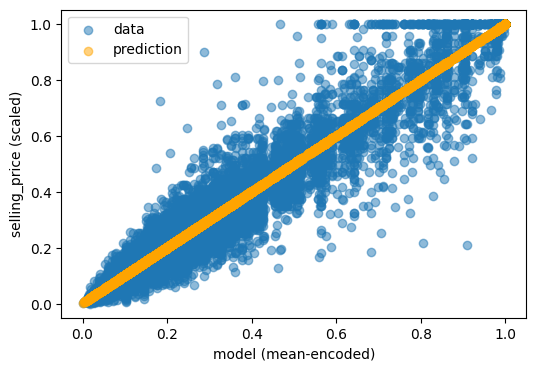

In [57]:
y_hat_uni = uni_model.predict(X[['model']])

plt.figure(figsize=(6, 4))
plt.scatter(X[['model']], y, label='data', alpha=0.5)
plt.scatter(X[['model']], y_hat_uni, color='orange', label='prediction', alpha=0.5)
plt.xlabel('model (mean-encoded)')
plt.ylabel('selling_price (scaled)')
plt.legend()
plt.show()

In [58]:
model = LinearRegression()
model.fit(X_train, y_train)

model.coef_, model.intercept_

(array([ 0.12588418, -0.25016952, -0.228541  ,  0.07508445,  0.04530473,
        -0.12588418,  0.06460638,  0.86034164, -0.00702006, -0.00703094,
         0.00672347,  0.1292155 ,  0.01603964, -0.00661902, -0.00390528,
        -0.01629955, -0.02359347]),
 np.float64(-0.011456351039686896))

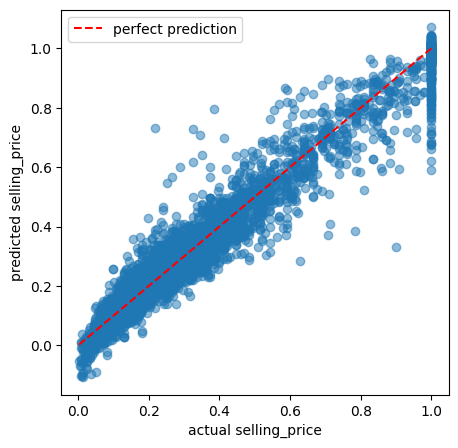

In [59]:
y_hat = model.predict(X_test)

plt.figure(figsize=(5, 5))
plt.scatter(y_test, y_hat, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='perfect prediction')
plt.xlabel('actual selling_price')
plt.ylabel('predicted selling_price')
plt.legend()
plt.show()

## 3. Evaluation of regression models

In [60]:
def r2_score(y, y_pred):
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1 - ss_res / ss_tot

def adj_r2_score(r_sq, X, y):
    n, p = X.shape[0], X.shape[1]
    return 1 - ((1 - r_sq) * (n - 1)) / (n - p - 1)

In [61]:
print('Train R2:', model.score(X_train, y_train))
print('Test  R2:', model.score(X_test, y_test))

Train R2: 0.9457591024750988
Test  R2: 0.9458843076992296


In [62]:
test_r2 = r2_score(y_test.values, model.predict(X_test))
print('Test R2 (manual):', test_r2)
print('Test Adjusted R2:', adj_r2_score(test_r2, X_test, y_test))

Test R2 (manual): 0.9458843076992296
Test Adjusted R2: 0.9457291176234682


## 4. Polynomial regression

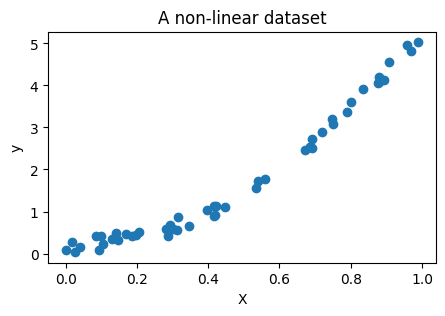

In [63]:
np.random.seed(1)
X_poly_demo = np.random.rand(50, 1)
y_poly_demo = (
    0.7 * X_poly_demo ** 5
    - 2.1 * X_poly_demo ** 4
    + 2.7 * X_poly_demo ** 3
    + 3.5 * X_poly_demo ** 2
    + 0.3 * X_poly_demo
    + 0.4 * np.random.rand(50, 1)  # noise
)

plt.figure(figsize=(5, 3))
plt.scatter(X_poly_demo, y_poly_demo)
plt.xlabel('X')
plt.ylabel('y')
plt.title('A non-linear dataset')
plt.show()

R2: 0.9345996128366808


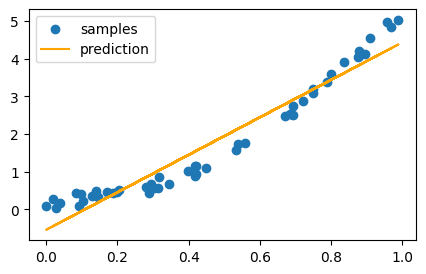

In [64]:
lin_demo = LinearRegression()
lin_demo.fit(X_poly_demo, y_poly_demo)
pred_demo = lin_demo.predict(X_poly_demo)

print('R2:', r2_score(y_poly_demo, pred_demo))

plt.figure(figsize=(5, 3))
plt.scatter(X_poly_demo, y_poly_demo, label='samples')
plt.plot(X_poly_demo, pred_demo, label='prediction', color='orange')
plt.legend()
plt.show()

Adj. R2 (degree 2): 0.9947910474710182


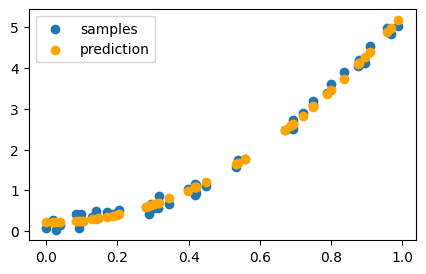

In [65]:
X_deg2 = np.hstack([X_poly_demo, X_poly_demo ** 2])

model_deg2 = LinearRegression()
model_deg2.fit(X_deg2, y_poly_demo)
pred_deg2 = model_deg2.predict(X_deg2)

r2_deg2 = r2_score(y_poly_demo, pred_deg2)
print('Adj. R2 (degree 2):', adj_r2_score(r2_deg2, X_poly_demo, y_poly_demo))

plt.figure(figsize=(5, 3))
plt.scatter(X_poly_demo, y_poly_demo, label='samples')
plt.scatter(X_poly_demo, pred_deg2, color='orange', label='prediction')
plt.legend()
plt.show()

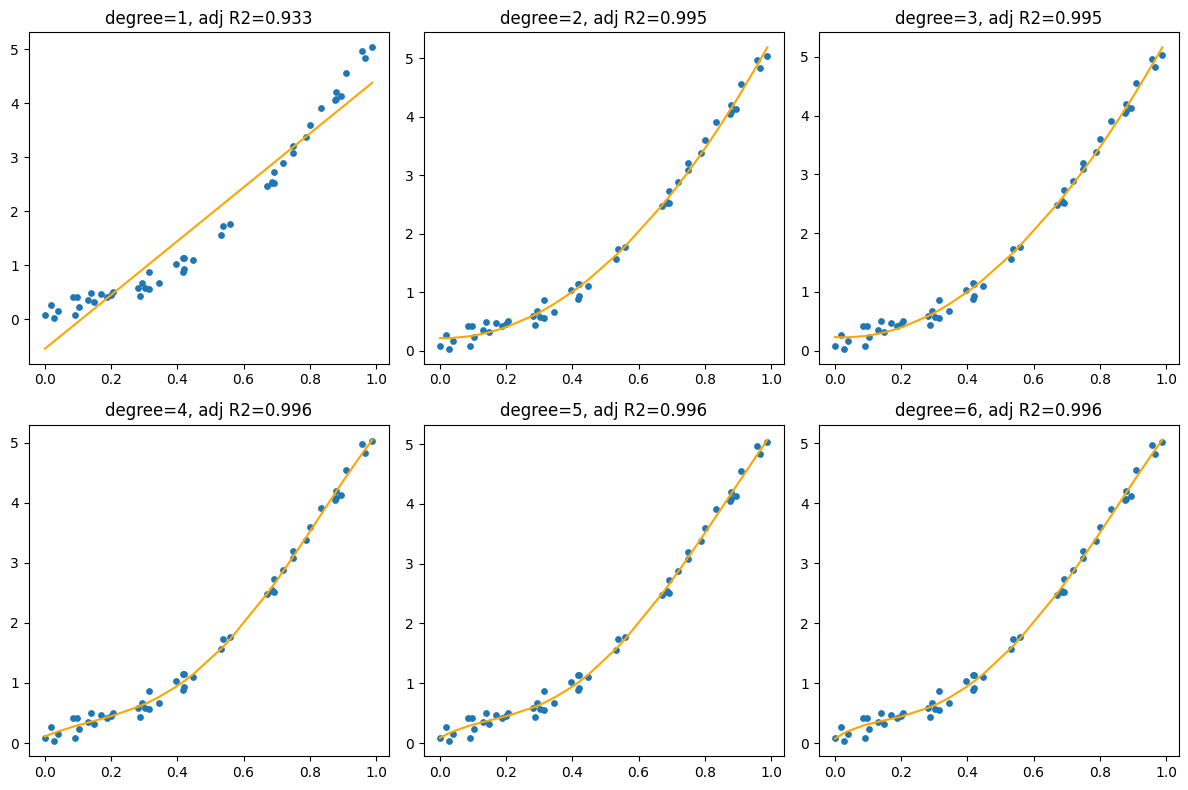

In [66]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.ravel()

for d in range(1, 7):
    poly = PolynomialFeatures(degree=d, include_bias=False)
    X_d = poly.fit_transform(X_poly_demo)

    m = LinearRegression()
    m.fit(X_d, y_poly_demo)
    pred_d = m.predict(X_d)
    r2_d = r2_score(y_poly_demo, pred_d)
    adj_d = adj_r2_score(r2_d, X_poly_demo, y_poly_demo)

    order = np.argsort(X_poly_demo[:, 0])
    axes[d - 1].scatter(X_poly_demo, y_poly_demo, s=15)
    axes[d - 1].plot(X_poly_demo[order], pred_d[order], color='orange')
    axes[d - 1].set_title(f'degree={d}, adj R2={adj_d:.3f}')

plt.tight_layout()
plt.show()

## 5. Underfitting, overfitting and bias variance

In [67]:
np.random.seed(1)
X_bv = np.random.rand(100, 1)
y_bv = (
    0.7 * X_bv ** 5 - 2.1 * X_bv ** 4 + 2.7 * X_bv ** 3
    + 3.5 * X_bv ** 2 + 0.3 * X_bv + 0.4 * np.random.rand(100, 1)
)

Xb_train, Xb_test, yb_train, yb_test = train_test_split(X_bv, y_bv, test_size=0.3, random_state=1)

train_scores, test_scores = [], []
degrees = range(1, 30)

for d in degrees:
    poly = PolynomialFeatures(degree=d, include_bias=False)
    Xb_train_d = poly.fit_transform(Xb_train)
    Xb_test_d = poly.transform(Xb_test)

    m = LinearRegression()
    m.fit(Xb_train_d, yb_train)

    train_r2 = r2_score(yb_train, m.predict(Xb_train_d))
    test_r2 = r2_score(yb_test, m.predict(Xb_test_d))
    train_scores.append(adj_r2_score(train_r2, Xb_train_d, yb_train))
    test_scores.append(adj_r2_score(test_r2, Xb_test_d, yb_test))

/tmp/ipykernel_2518/1985437065.py:8: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - ((1 - r_sq) * (n - 1)) / (n - p - 1)


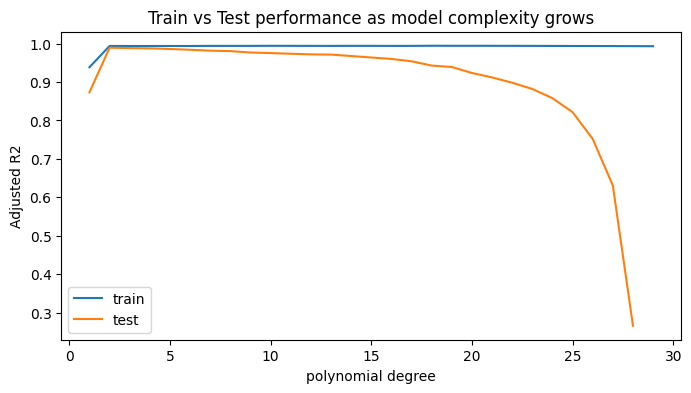

In [68]:
plt.figure(figsize=(8, 4))
plt.plot(list(degrees), train_scores, label='train')
plt.plot(list(degrees), test_scores, label='test')
plt.xlabel('polynomial degree')
plt.ylabel('Adjusted R2')
plt.legend()
plt.title('Train vs Test performance as model complexity grows')
plt.show()

## 6. Regularization:- ridge, lasso and elasticnet

In [69]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

overfit_degree = 25
poly_of = PolynomialFeatures(degree=overfit_degree, include_bias=False)
Xb_train_of = poly_of.fit_transform(Xb_train)
Xb_test_of = poly_of.transform(Xb_test)

poly_scaler = StandardScaler()
Xb_train_of_scaled = poly_scaler.fit_transform(Xb_train_of)
Xb_test_of_scaled = poly_scaler.transform(Xb_test_of)

plain_of = LinearRegression()
plain_of.fit(Xb_train_of_scaled, yb_train)

print('Plain Linear Regression, degree =', overfit_degree)
print('  Train MSE:', mean_squared_error(yb_train, plain_of.predict(Xb_train_of_scaled)))
print('  Test  MSE:', mean_squared_error(yb_test, plain_of.predict(Xb_test_of_scaled)))

Plain Linear Regression, degree = 25
  Train MSE: 0.010287929108736386
  Test  MSE: 0.04082622122487044


In [70]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

ridge_of = Ridge(alpha=1.0)
lasso_of = Lasso(alpha=0.01)
elastic_of = ElasticNet(alpha=0.01, l1_ratio=0.5)

for name, m in [('Ridge', ridge_of), ('Lasso', lasso_of), ('ElasticNet', elastic_of)]:
    m.fit(Xb_train_of_scaled, yb_train)
    train_mse = mean_squared_error(yb_train, m.predict(Xb_train_of_scaled))
    test_mse = mean_squared_error(yb_test, m.predict(Xb_test_of_scaled))
    print(f'{name:10s}  train MSE={train_mse:.5f}   test MSE={test_mse:.5f}')

Ridge       train MSE=0.01678   test MSE=0.02249
Lasso       train MSE=0.01552   test MSE=0.01754
ElasticNet  train MSE=0.01632   test MSE=0.02178


In [71]:
n_zero_lasso = np.sum(np.isclose(lasso_of.coef_, 0))
n_zero_ridge = np.sum(np.isclose(ridge_of.coef_, 0))

print(f'Lasso: {n_zero_lasso} / {len(lasso_of.coef_)} weights driven to (near) zero')
print(f'Ridge: {n_zero_ridge} / {len(ridge_of.coef_)} weights driven to (near) zero')


Lasso: 22 / 25 weights driven to (near) zero
Ridge: 0 / 25 weights driven to (near) zero


## 7. Hyperparameters and tuning them

In [72]:
def adj_r2(X, y, r2):
    return 1 - ((1 - r2) * (len(y) - 1)) / (len(y) - X.shape[1] - 1)

In [73]:
from sklearn.pipeline import make_pipeline

np.random.seed(2)
X_ht = np.random.rand(1000, 1)
y_ht = (
    0.7 * X_ht ** 5 - 2.1 * X_ht ** 4 + 2.3 * X_ht ** 3
    + 0.2 * X_ht ** 2 + 0.3 * X_ht + 0.4 * np.random.rand(1000, 1)
)

Xht_train, Xht_test, yht_train, yht_test = train_test_split(X_ht, y_ht, test_size=0.2, random_state=1)
Xht_train.shape, Xht_test.shape

((800, 1), (200, 1))

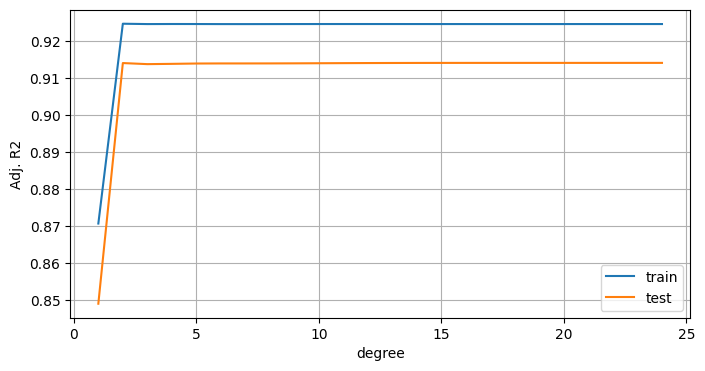

In [74]:
max_degree = 25
train_scores, test_scores = [], []
scaler_ht = StandardScaler()

for degree in range(1, max_degree):
    pipe = make_pipeline(PolynomialFeatures(degree), scaler_ht, Ridge())
    pipe.fit(Xht_train, yht_train)
    train_scores.append(adj_r2(Xht_train, yht_train, pipe.score(Xht_train, yht_train)))
    test_scores.append(adj_r2(Xht_test, yht_test, pipe.score(Xht_test, yht_test)))

plt.figure(figsize=(8, 4))
plt.plot(range(1, max_degree), train_scores, label='train')
plt.plot(range(1, max_degree), test_scores, label='test')
plt.xlabel('degree')
plt.ylabel('Adj. R2')
plt.legend()
plt.grid(True)
plt.show()

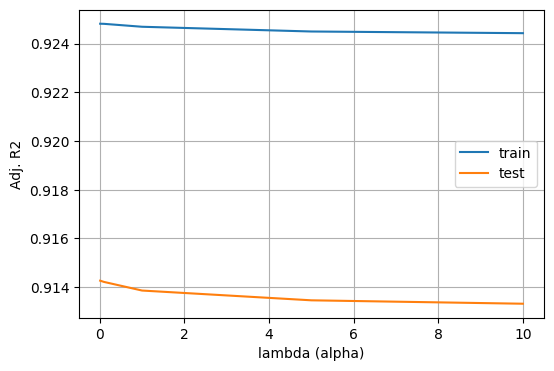

[0.9142688321768443,
 0.9142176328264028,
 0.9138636295262608,
 0.9134626780435391,
 0.9133227560134852]

In [75]:
train_scores, test_scores = [], []
rate_list = [0.01, 0.1, 1, 5, 10]

for rate in rate_list:
    pipe = make_pipeline(PolynomialFeatures(3), scaler_ht, Ridge(alpha=rate))
    pipe.fit(Xht_train, yht_train)
    train_scores.append(adj_r2(Xht_train, yht_train, pipe.score(Xht_train, yht_train)))
    test_scores.append(adj_r2(Xht_test, yht_test, pipe.score(Xht_test, yht_test)))

plt.figure(figsize=(6, 4))
plt.plot(rate_list, train_scores, label='train')
plt.plot(rate_list, test_scores, label='test')
plt.xlabel('lambda (alpha)')
plt.ylabel('Adj. R2')
plt.legend()
plt.grid(True)
plt.show()

test_scores

## 8. Cross validation

In [76]:
X_tr_cv, Xcv_test, y_tr_cv, ycv_test = train_test_split(X_ht, y_ht, test_size=0.2, random_state=1)
Xcv_train, Xcv_val, ycv_train, ycv_val = train_test_split(X_tr_cv, y_tr_cv, test_size=0.25, random_state=1)

Xcv_train.shape, Xcv_val.shape, Xcv_test.shape

((600, 1), (200, 1), (200, 1))

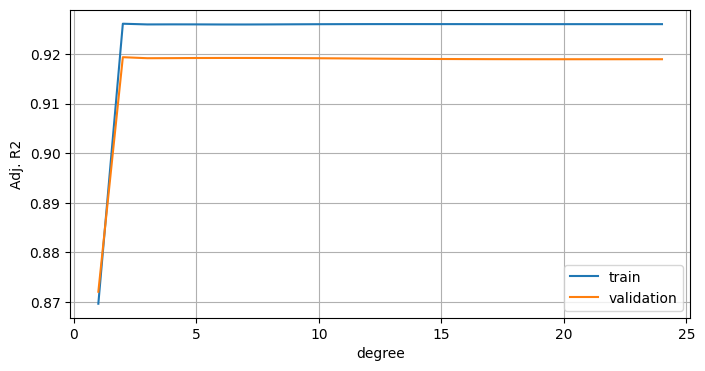

In [77]:
max_degree = 25
train_scores, val_scores = [], []
scaler_cv = StandardScaler()

for degree in range(1, max_degree):
    pipe = make_pipeline(PolynomialFeatures(degree), scaler_cv, Ridge())
    pipe.fit(Xcv_train, ycv_train)
    train_scores.append(adj_r2(Xcv_train, ycv_train, pipe.score(Xcv_train, ycv_train)))
    val_scores.append(adj_r2(Xcv_val, ycv_val, pipe.score(Xcv_val, ycv_val)))

plt.figure(figsize=(8, 4))
plt.plot(range(1, max_degree), train_scores, label='train')
plt.plot(range(1, max_degree), val_scores, label='validation')
plt.xlabel('degree')
plt.ylabel('Adj. R2')
plt.legend()
plt.grid(True)
plt.show()

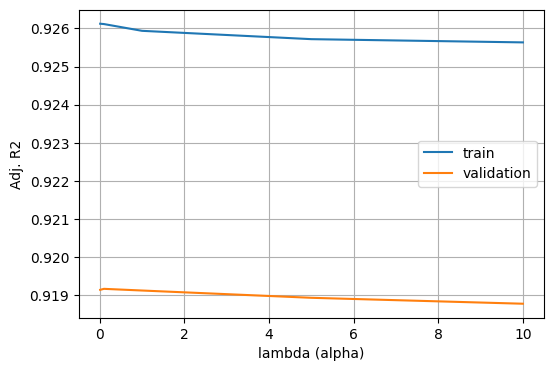

In [78]:
train_scores, val_scores = [], []
rate_list = [0.01, 0.1, 1, 5, 10]

for rate in rate_list:
    pipe = make_pipeline(PolynomialFeatures(3), scaler_cv, Ridge(alpha=rate))
    pipe.fit(Xcv_train, ycv_train)
    train_scores.append(adj_r2(Xcv_train, ycv_train, pipe.score(Xcv_train, ycv_train)))
    val_scores.append(adj_r2(Xcv_val, ycv_val, pipe.score(Xcv_val, ycv_val)))

plt.figure(figsize=(6, 4))
plt.plot(rate_list, train_scores, label='train')
plt.plot(rate_list, val_scores, label='validation')
plt.xlabel('lambda (alpha)')
plt.ylabel('Adj. R2')
plt.legend()
plt.grid(True)
plt.show()

In [79]:
final_pipe = make_pipeline(PolynomialFeatures(3), scaler_cv, Ridge(alpha=0.01))
final_pipe.fit(Xcv_train, ycv_train)

print('Training Score:  ', adj_r2(Xcv_train, ycv_train, final_pipe.score(Xcv_train, ycv_train)))
print('Validation Score:', adj_r2(Xcv_val, ycv_val, final_pipe.score(Xcv_val, ycv_val)))
print('Test Score:      ', adj_r2(Xcv_test, ycv_test, final_pipe.score(Xcv_test, ycv_test)))

Training Score:   0.9261212571628987
Validation Score: 0.9191482611247953
Test Score:       0.9143625261065258


## 9. K fold cross validation

In [80]:
np.random.seed(2)
X_kf = np.random.rand(100, 1)
y_kf = (
    0.7 * X_kf ** 5 - 2.1 * X_kf ** 4 + 2.3 * X_kf ** 3
    + 0.2 * X_kf ** 2 + 0.3 * X_kf + 0.4 * np.random.rand(100, 1)
)

In [81]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=10)

In [82]:
max_degree = 15
train_scores, val_scores = [], []
scaler_kf = StandardScaler()

for degree in range(1, max_degree):
    fold_train, fold_val = [], []
    for train_idx, val_idx in kf.split(X_kf):
        X_tr_fold, X_val_fold = X_kf[train_idx], X_kf[val_idx]
        y_tr_fold, y_val_fold = y_kf[train_idx], y_kf[val_idx]

        pipe = make_pipeline(PolynomialFeatures(degree), scaler_kf, LinearRegression())
        pipe.fit(X_tr_fold, y_tr_fold)

        fold_train.append(pipe.score(X_tr_fold, y_tr_fold))
        fold_val.append(pipe.score(X_val_fold, y_val_fold))

    train_scores.append(np.mean(fold_train))
    val_scores.append(np.mean(fold_val))

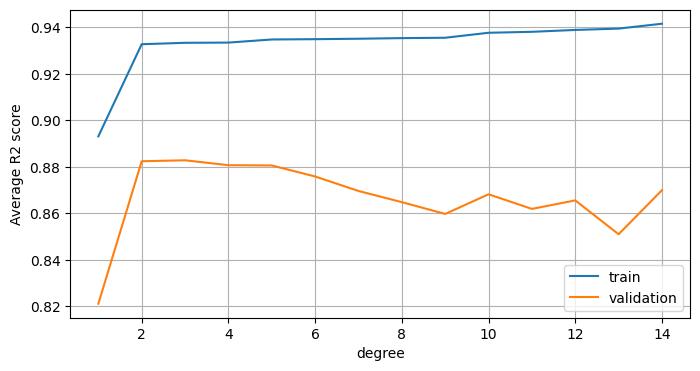

In [83]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, max_degree), train_scores, label='train')
plt.plot(range(1, max_degree), val_scores, label='validation')
plt.xlabel('degree')
plt.ylabel('Average R2 score')
plt.legend()
plt.grid(True)
plt.show()

## 10. Linear regression without libraries

In [84]:
class LinearRegressionScratch:
    def __init__(self, learning_rate=0.01, iterations=5):
        self.learning_rate = learning_rate
        self.iterations = iterations

In [85]:
def predict(self, X):
    return np.dot(X, self.W) + self.b

LinearRegressionScratch.predict = predict

In [86]:
def r2_score_method(self, X, y):
    y_pred = self.predict(X)
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    return 1 - ss_res / ss_tot

LinearRegressionScratch.score = r2_score_method

In [87]:
def update_weights(self):
    y_pred = self.predict(self.X)

    dW = -(2 * self.X.T.dot(self.Y - y_pred)) / self.m
    db = -2 * np.sum(self.Y - y_pred) / self.m

    self.W = self.W - self.learning_rate * dW
    self.b = self.b - self.learning_rate * db

    loss = np.mean((self.Y - y_pred) ** 2)
    self.error_list.append(loss)
    return self

LinearRegressionScratch.update_weights = update_weights

In [88]:
def fit(self, X, Y):
    self.m, self.d = X.shape
    self.W = np.zeros(self.d)
    self.b = 0
    self.X = np.asarray(X)
    self.Y = np.asarray(Y)
    self.error_list = []

    for _ in range(self.iterations):
        self.update_weights()
    return self

LinearRegressionScratch.fit = fit

In [89]:
scratch_model = LinearRegressionScratch(learning_rate=0.1, iterations=200)
scratch_model.fit(X_train, y_train)

print('Train R2:', scratch_model.score(X_train, np.asarray(y_train)))
print('Test  R2:', scratch_model.score(X_test, np.asarray(y_test)))

Train R2: 0.9110443338167872
Test  R2: 0.9115517236305655


In [90]:
print('sklearn  coef:', model.coef_[:5])
print('scratch  coef:', scratch_model.W[:5])
print('sklearn  intercept:', model.intercept_)
print('scratch  intercept:', scratch_model.b)

sklearn  coef: [ 0.12588418 -0.25016952 -0.228541    0.07508445  0.04530473]
scratch  coef: [ 0.16967006 -0.00812774 -0.01793535  0.08536262  0.1140595 ]
sklearn  intercept: -0.011456351039686896
scratch  intercept: 0.031232332867923318


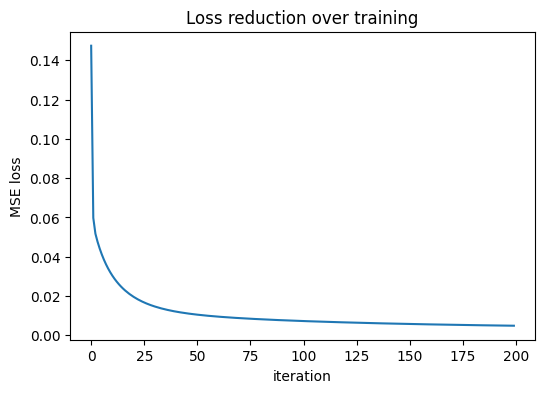

In [91]:
plt.figure(figsize=(6, 4))
plt.plot(scratch_model.error_list)
plt.xlabel('iteration')
plt.ylabel('MSE loss')
plt.title('Loss reduction over training')
plt.show()

## 11. Linear regression with stats model

In [93]:
import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train)

ols_model = sm.OLS(y_train, X_train_sm)
ols_results = ols_model.fit()
print(ols_results.summary())

                            OLS Regression Results                            
Dep. Variable:          selling_price   R-squared:                       0.946
Model:                            OLS   Adj. R-squared:                  0.946
Method:                 Least Squares   F-statistic:                 1.514e+04
Date:                Thu, 10 Sep 2026   Prob (F-statistic):               0.00
Time:                        15:19:04   Log-Likelihood:                 20683.
No. Observations:               13874   AIC:                        -4.133e+04
Df Residuals:                   13857   BIC:                        -4.120e+04
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -6.744e+11   1.16e+11  

/tmp/ipykernel_2518/3935924453.py:6: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ols_results = ols_model.fit()


In [94]:
(ols_results.predict(X_train_sm).values[:5], model.predict(X_train)[:5])

(array([0.12519777, 1.00237884, 0.35620533, 0.25561945, 0.20037616]),
 array([0.12906117, 1.00037665, 0.3589149 , 0.25985213, 0.19988865]))

## 13. multi collinearity

In [95]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_train_scaled_df = pd.DataFrame(X_train.values, columns=X_train.columns)

vif = pd.DataFrame()
vif['Feature'] = X_train_scaled_df.columns
vif['VIF'] = [variance_inflation_factor(X_train_scaled_df.values, i)
              for i in range(X_train_scaled_df.shape[1])]
vif = vif.sort_values('VIF', ascending=False).reset_index(drop=True)
vif

/tmp/ipykernel_2518/1872706095.py:7: UserWarning: The design matrix is poorly conditioned (condition number=8.63e+13). VIF calculations may be numerically unstable.
  vif['VIF'] = [variance_inflation_factor(X_train_scaled_df.values, i)


,Feature,VIF
0,year,1.000800e+15
1,age,1.000800e+15
2,Petrol,1.918900e+01
3,Diesel,1.820561e+01
4,>5,1.300100e+01
5,5,1.186808e+01
6,engine,6.180960e+00
7,model,6.171542e+00
8,max_power,5.060184e+00
9,make,3.308877e+00


In [97]:
vif_threshold = 5
remaining_cols = list(X_train_scaled_df.columns)

while True:
    vif_iter = pd.DataFrame()
    vif_iter['Feature'] = remaining_cols
    vif_iter['VIF'] = [variance_inflation_factor(X_train_scaled_df[remaining_cols].values, i)
                        for i in range(len(remaining_cols))]
    max_vif = vif_iter['VIF'].max()
    if max_vif < vif_threshold or len(remaining_cols) <= 1:
        break
    worst_feature = vif_iter.sort_values('VIF', ascending=False).iloc[0]['Feature']
    remaining_cols.remove(worst_feature)

print('Features kept after VIF filtering:', remaining_cols)
vif_iter.sort_values('VIF', ascending=False)

/tmp/ipykernel_2518/1923721574.py:7: UserWarning: The design matrix is poorly conditioned (condition number=8.63e+13). VIF calculations may be numerically unstable.
  vif_iter['VIF'] = [variance_inflation_factor(X_train_scaled_df[remaining_cols].values, i)
/tmp/ipykernel_2518/1923721574.py:7: UserWarning: The design matrix is poorly conditioned (condition number=8.63e+13). VIF calculations may be numerically unstable.
  vif_iter['VIF'] = [variance_inflation_factor(X_train_scaled_df[remaining_cols].values, i)
/tmp/ipykernel_2518/1923721574.py:7: UserWarning: The design matrix is poorly conditioned (condition number=8.63e+13). VIF calculations may be numerically unstable.
  vif_iter['VIF'] = [variance_inflation_factor(X_train_scaled_df[remaining_cols].values, i)
/tmp/ipykernel_2518/1923721574.py:7: UserWarning: The design matrix is poorly conditioned (condition number=8.63e+13). VIF calculations may be numerically unstable.
  vif_iter['VIF'] = [variance_inflation_factor(X_train_scaled_df

Features kept after VIF filtering: ['km_driven', 'mileage', 'max_power', 'age', 'make', 'Individual', 'Trustmark Dealer', 'Diesel', 'Electric', 'LPG', 'Manual', '5']


,Feature,VIF
2,max_power,2.661157
4,make,2.361805
1,mileage,2.214856
10,Manual,1.656437
7,Diesel,1.524029
11,5,1.446399
3,age,1.298476
0,km_driven,1.184581
8,Electric,1.138179
5,Individual,1.085842


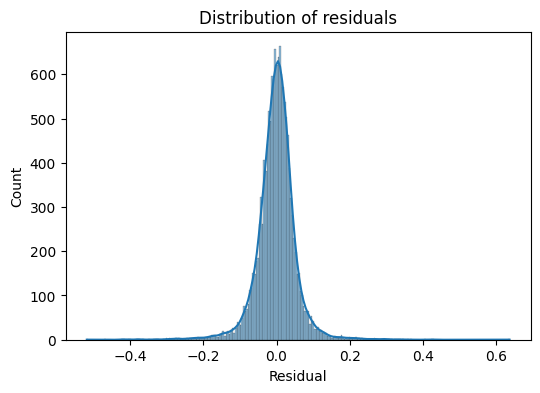

In [98]:
residuals = ols_results.predict(X_train_sm) - y_train

plt.figure(figsize=(6, 4))
sns.histplot(residuals, kde=True)
plt.xlabel('Residual')
plt.title('Distribution of residuals')
plt.show()

In [99]:
from scipy import stats

shapiro_result = stats.shapiro(residuals)
print('Shapiro-Wilk statistic:', shapiro_result.statistic, ' p-value:', shapiro_result.pvalue)

Shapiro-Wilk statistic: 0.899234731341193  p-value: 3.334774190571293e-69


/usr/local/lib/python3.13/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 13874.
  res = hypotest_fun_out(*samples, **kwds)


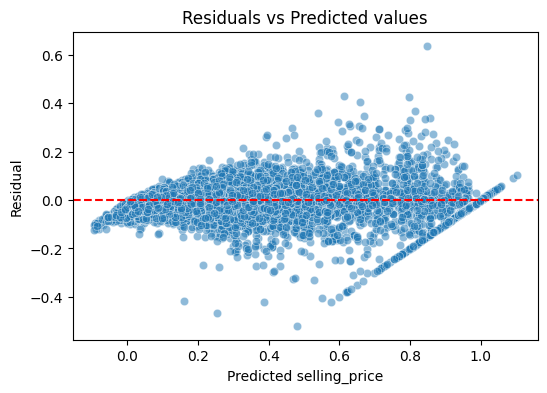

In [100]:
fitted_vals = ols_results.predict(X_train_sm)

plt.figure(figsize=(6, 4))
sns.scatterplot(x=fitted_vals, y=residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted selling_price')
plt.ylabel('Residual')
plt.title('Residuals vs Predicted values')
plt.show()

In [102]:
import statsmodels.stats.api as sms

gq_stat, gq_pvalue, _ = sms.het_goldfeldquandt(y_train, X_train_sm)
print(f'F statistic: {gq_stat:.3f},  p-value: {gq_pvalue:.3f}')

F statistic: 1.024,  p-value: 0.164


/usr/local/lib/python3.13/dist-packages/statsmodels/stats/diagnostic.py:1412: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  resols1 = OLS(y[:split], x[:split]).fit()
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/diagnostic.py:1413: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  resols2 = OLS(y[start2:], x[start2:]).fit()
/tmp/ipykernel_2518/1628412833.py:3: FutureWarning: het_goldfeldquandt currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning a GoldfeldQuandtResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  gq_stat, gq_pvalue, _ = sms.het_goldfeldquandt(y_train, X_train_sm)
